# CNN multilabel básica con Keras

Este notebook muestra un flujo mínimo y reproducible para entrenar una red neuronal convolucional (CNN) en un problema **multietiqueta**.

Objetivos:
1. Construir etiquetas multilabel a partir de MNIST.
2. Entrenar una CNN con salida sigmoide y pérdida `binary_crossentropy` (salida y pérdida habitual para CNN multilabel).
3. Evaluar con métricas adecuadas para multilabel (exact match y F1 micro).

## Fundamento breve

- En clasificación **multilabel**, una imagen puede pertenecer simultáneamente a varias clases; por eso usamos una neurona de salida por etiqueta con activación **sigmoide**.
- La pérdida estándar es **binary cross-entropy** aplicada por etiqueta y agregada sobre el vector de salida.
- En CNN, las capas convolucionales aprenden filtros locales con pesos compartidos y suelen alternarse con pooling para reducir dimensionalidad.

# Consideraciones

Para asegurar el correcto funcionamiento del notebook se recomienda usar un entorno virtual de conda. Para ello, siga los siguiente pasos:

* `conda create -n <nombre_entorno> python=3.11 -y`
* `conda activate <nombre_entorno>`

Una vez creado y activado el entorno virtual:
* ``pip install jupyter``
* ``pip install ipykernel``
* ``pip install numpy``
* ``pip install matplotlib``
* ``pip install tensorflow``

> Nota: se puede hacer un único pip install con todos los paquetes en una sola instrucción, pero para mayor claridad se han separado en distintos installs.

Y finalmente registramos el kernel para Jupyter:
* `python -m ipykernel install --user --name <nombre_entorno> --display-name <nombre_display>`

Una vez seguidos estos pasos, todas las celdas del Notebook deberían poder ejecutarse sin problema.

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fijamos la semilla para obtener resultados reproducibles
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

#He tenido algún problema con esto, era para comprobar la versión
print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


In [3]:
# Cargamos MNIST (imágenes 28x28 en escala de grises)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizamos las imágenes y añadimos un canal para que sean compatibles con las capas convolucionales
x_train = (x_train.astype('float32') / 255.0)[..., np.newaxis]
x_test = (x_test.astype('float32') / 255.0)[..., np.newaxis]

print('x_train:', x_train.shape, 'x_test:', x_test.shape)

x_train: (60000, 28, 28, 1) x_test: (10000, 28, 28, 1)


## Construcción de etiquetas multilabel

Cada muestra tendrá 13 etiquetas binarias:
- 10 etiquetas para el dígito (`digit_0` ... `digit_9`)
- `is_even`
- `is_prime`
- `is_ge_5`

Así, una misma imagen activa varias etiquetas a la vez (por ejemplo, un 8 activa `digit_8`, `is_even` y `is_ge_5`).

In [4]:
def build_multilabel_targets(y):
    y = y.astype(int)
    n = y.shape[0]

    # 10 etiquetas one-hot del dígito
    digit_one_hot = keras.utils.to_categorical(y, num_classes=10)

    # 3 etiquetas binarias adicionales
    is_even = (y % 2 == 0).astype('float32').reshape(n, 1)
    is_prime = np.isin(y, [2, 3, 5, 7]).astype('float32').reshape(n, 1)
    is_ge_5 = (y >= 5).astype('float32').reshape(n, 1)

    # Se concatenan las etiquetas en un array
    return np.concatenate([digit_one_hot, is_even, is_prime, is_ge_5], axis=1).astype('float32')

y_train_ml = build_multilabel_targets(y_train)
y_test_ml = build_multilabel_targets(y_test)

label_names = [f'digit_{i}' for i in range(10)] + ['is_even', 'is_prime', 'is_ge_5']
print('Etiquetas:', label_names)
print('y_train_ml shape:', y_train_ml.shape)
print('Etiquetas por muestra (media):', y_train_ml.sum(axis=1).mean())

Etiquetas: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9', 'is_even', 'is_prime', 'is_ge_5']
y_train_ml shape: (60000, 13)
Etiquetas por muestra (media): 2.37785


In [5]:
# Subconjunto para entrenamiento rápido de ejemplo
n_train = 20000
n_val = 5000

x_train_small = x_train[:n_train]
y_train_small = y_train_ml[:n_train]

x_val = x_train[n_train:n_train+n_val]
y_val = y_train_ml[n_train:n_train+n_val]

print('train:', x_train_small.shape, y_train_small.shape)
print('val:', x_val.shape, y_val.shape)

train: (20000, 28, 28, 1) (20000, 13)
val: (5000, 28, 28, 1) (5000, 13)


## Modelo CNN en Keras

Diseño mínimo:
- Dos bloques `Conv2D + MaxPooling2D` para extraer características espaciales. Aquí se usa ReLU para que la red aprenda patrones complejos (para las primeras capas es mejor ya que es barata de calcular y entrena más rápido).
- `Dense` intermedia para combinar características (útil para predecir etiquetas a partir de ciertos patrones).
- Capa final de 13 neuronas con `sigmoid` (una probabilidad por etiqueta).

In [ ]:
num_labels = y_train_ml.shape[1]

# Modelo CNN para clasificación multilabel
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_labels, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.BinaryAccuracy(name='bin_acc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,029 (1.61 MB)

 Trainable params: 422,029 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del modelo

history = model.fit(
    x_train_small, y_train_small,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - bin_acc: 0.9304 - loss: 0.1777 - val_bin_acc: 0.9844 - val_loss: 0.0451
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - bin_acc: 0.9844 - loss: 0.0456 - val_bin_acc: 0.9921 - val_loss: 0.0243
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - bin_acc: 0.9897 - loss: 0.0302 - val_bin_acc: 0.9942 - val_loss: 0.0179
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - bin_acc: 0.9922 - loss: 0.0233 - val_bin_acc: 0.9950 - val_loss: 0.0157
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - bin_acc: 0.9939 - loss: 0.0181 - val_bin_acc: 0.9951 - val_loss: 0.0141


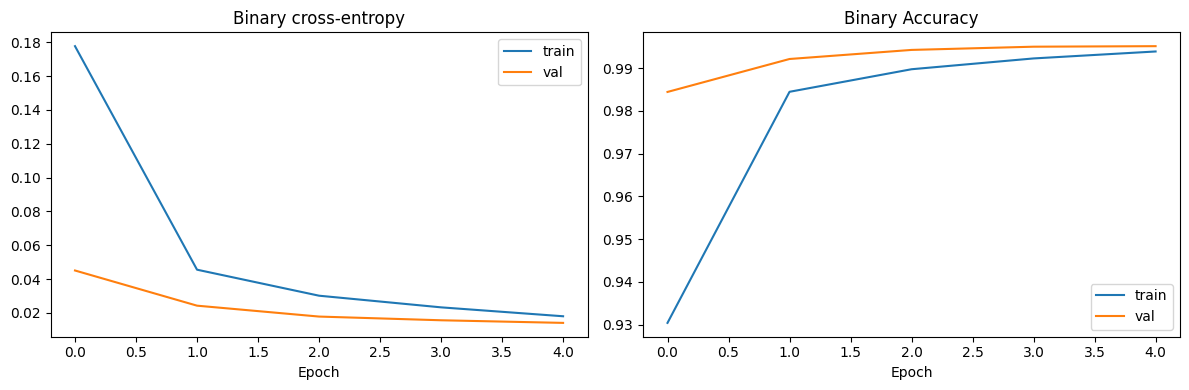

In [ ]:
# Visualizamos una predicción de ejemplo

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Binary cross-entropy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['bin_acc'], label='train')
axes[1].plot(history.history['val_bin_acc'], label='val')
axes[1].set_title('Binary Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Evaluación en test
test_loss, test_bin_acc = model.evaluate(x_test, y_test_ml, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test binary accuracy: {test_bin_acc:.4f}')

# Predicciones multilabel con umbral
threshold = 0.5
y_prob = model.predict(x_test, verbose=0)
y_pred = (y_prob >= threshold).astype('float32')

# Exact match ratio
exact_match = (y_pred == y_test_ml).all(axis=1).mean()

# F1 micro (cálculo directo)
tp = np.logical_and(y_pred == 1, y_test_ml == 1).sum()
fp = np.logical_and(y_pred == 1, y_test_ml == 0).sum()
fn = np.logical_and(y_pred == 0, y_test_ml == 1).sum()

precision_micro = tp / (tp + fp + 1e-8)
recall_micro = tp / (tp + fn + 1e-8)
f1_micro = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + 1e-8)

print(f'Exact match ratio: {exact_match:.4f}')
print(f'Precision micro: {precision_micro:.4f}')
print(f'Recall micro: {recall_micro:.4f}')
print(f'F1 micro: {f1_micro:.4f}')

Test loss: 0.0131
Test binary accuracy: 0.9955
Exact match ratio: 0.9697
Precision micro: 0.9906
Recall micro: 0.9846
F1 micro: 0.9876


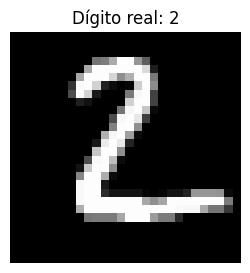

Vector de predicción de cada etiqueta: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
Etiquetas reales: ['digit_2', 'is_even', 'is_prime']
Etiquetas predichas: ['digit_2', 'is_even', 'is_prime']


In [15]:
# Visualizamos una predicción de ejemplo
idx = 1
img = x_test[idx]
true_vec = y_test_ml[idx]
pred_vec = y_pred[idx]

true_labels = [label_names[i] for i in np.where(true_vec == 1)[0]]
pred_labels = [label_names[i] for i in np.where(pred_vec == 1)[0]]

plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')
plt.title(f'Dígito real: {y_test[idx]}')
plt.show()

print('Vector de predicción de cada etiqueta:', pred_vec)
print('Etiquetas reales:', true_labels)
print('Etiquetas predichas:', pred_labels)

## Referencias

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Capítulo 9: Convolutional Networks.
   - https://www.deeplearningbook.org/contents/convnets.html

2. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning. Capítulos sobre CNN en Keras y pipelines de entrenamiento.
   - https://sourestdeeds.github.io/pdf/Deep%20Learning%20with%20Python.pdf

3. Zhang, M.-L., & Zhou, Z.-H. (2014). A Review on Multi-Label Learning Algorithms. *IEEE Transactions on Knowledge and Data Engineering*, 26(8), 1819–1837.
   - https://doi.org/10.1109/TKDE.2013.39

4. Stanford CS231n (Fei-Fei Li, Justin Johnson, Serena Yeung). *Convolutional Neural Networks for Visual Recognition*. Material universitario, secciones sobre arquitecturas convolucionales y entrenamiento.
   - https://cs231n.github.io/convolutional-networks/